# Exploratory Data Analysis
Objective: visually explore how middle east conflicts drive india's fuel and gas prices

In [2]:

#* import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore') 

In [3]:

#^ plotting style
plt.rcParams['figure.figsize'] = (19, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

# Load datasets (master dataset & crude import data)

In [4]:

#~ Load data
df = pd.read_csv(r'C:\Users\anasq\OneDrive\Desktop\PetroAnalyst\Dataset\ML_Ready_Data\EDA_data.csv', parse_dates=['date'], dayfirst=True)

df = df.sort_values('date').reset_index(drop=True)

#todo crude import dependency datset
crude_import = pd.read_csv(r'C:\Users\anasq\OneDrive\Desktop\PetroAnalyst\Dataset\eda_crude_import_data\india_crude_import.csv')

#^ filter from 2010-11
crude_import = crude_import[crude_import['year'] >= '2010-11'].reset_index(drop=True)

#& inspection
print('Master dataset shape : ', df.shape)
print('Crude import dataset shape : ', crude_import.shape)
print('date range (master) : ', df['date'].iloc[0] , ' -> ', df['date'].iloc[-1])
print('date range (crude import) : ', crude_import['year'].iloc[0], ' -> ', crude_import['year'].iloc[-1])
print('columns (masters) : ', list(df.columns))
print('columns (crude import) : ', list(crude_import.columns))

Master dataset shape :  (189, 50)
Crude import dataset shape :  (16, 16)
date range (master) :  2010-07-01 00:00:00  ->  2026-03-01 00:00:00
date range (crude import) :  2010-11  ->  2025-26
columns (masters) :  ['date', 'brent_price', 'wti_price', 'GPR_index', 'INR/USD_rate', 'LPG_price', 'petrol_price', 'diesel_price', 'brent_lag1', 'brent_lag3', 'brent_lag6', 'wti_lag1', 'wti_lag3', 'GPR_lag1', 'GPR_lag3', 'usd_rate_lag1', 'usd_rate_lag3', 'lpg_price_lag1', 'lpg_price_lag3', 'petrol_price_lag1', 'petrol_price_lag3', 'diesel_price_lag1', 'diesel_price_lag3', 'brent_roll3', 'GPR_roll3', 'usd_rate_roll3', 'brent_roll6', 'GPR_roll6', 'brent_pct_change', 'wti_pct_change', 'GPR_pct_change', 'usd_pct_change', 'lpg_pct_change', 'petrol_pct_change', 'diesel_pct_change', 'conflict_event', 'risk_level', 'crude_inr_impact', 'conflict_crude_index', 'brent_wti_spread', 'inr_gpr_stress', 'crude_lpg_impact', 'lpg_momentum', 'conflict_intensity', 'GPR_outlier', 'brent_outlier', 'lpg_price_outlier', 

In [5]:
df

,date,brent_price,wti_price,GPR_index,INR/USD_rate,LPG_price,petrol_price,diesel_price,brent_lag1,brent_lag3,...,inr_gpr_stress,crude_lpg_impact,lpg_momentum,conflict_intensity,GPR_outlier,brent_outlier,lpg_price_outlier,petrol_price_outlier,diesel_price_outlier,usd_outliers
0,2010-07-01,75.58,76.32,79.38,46.7617,378.4,54.45,42.32,74.76,84.82,...,37.1194,9.3400,5.0,-0.7504,0,0,0,0,0,0
1,2010-08-01,77.04,76.60,80.99,46.4605,383.4,54.55,39.88,75.58,75.95,...,37.6284,9.3357,5.0,-0.6856,0,0,0,0,0,0
2,2010-09-01,77.84,75.24,71.17,45.8729,388.4,54.77,39.98,77.04,74.76,...,32.6477,9.1935,5.0,-0.9516,0,0,0,0,0,0
3,2010-10-01,82.67,81.89,65.99,44.3540,393.4,55.47,39.89,77.84,75.58,...,29.2692,9.3207,5.0,-1.0392,0,0,0,0,0,1
4,2010-11-01,85.28,84.25,94.71,44.9315,398.4,55.78,39.89,82.67,77.04,...,42.5546,9.6179,5.0,-0.2021,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,2025-11-01,63.80,60.06,104.34,88.8444,861.7,110.26,97.04,64.54,67.87,...,92.7002,6.5780,0.0,-0.2375,0,0,0,0,0,0
185,2025-12-01,62.54,57.97,131.39,90.0350,861.7,110.26,97.04,63.80,67.99,...,118.2970,6.5345,0.0,0.4993,0,0,0,0,0,0
186,2026-01-01,66.60,60.04,167.80,90.9025,861.7,107.26,94.04,62.54,64.54,...,152.5344,7.0258,0.0,1.5997,1,0,0,0,0,0
187,2026-02-01,70.89,64.51,121.62,90.7458,861.7,107.26,94.04,66.60,63.80,...,110.3650,7.4654,0.0,0.3705,0,0,0,0,0,0


# Statistical overview of data

In [6]:

#& Dataset overview
core_cols = ['brent_price', 'wti_price','GPR_index', 'LPG_price', 'INR/USD_rate', 'petrol_price', 'diesel_price']

print('='*10, ' DESCRIPTIVE STATISTICS', '='*10)
print(df[core_cols].describe().round(2))

#todo Risk map
print('\n\n\n', '='*10, ' Risk distribution ', '='*10)
risk_map = {0 : 'low', 1 : 'medium', 2 : 'high', 3 : 'critical'}
print(df['risk_level'].map(risk_map).value_counts())

#! conflict months
print('\n\n\n', '='*10, ' Conflict months ', '='*10)
print(df[df['conflict_event'] == 1][['date', 'GPR_index', 'brent_price', 'LPG_price', 'petrol_price', 'diesel_price', 'lpg_pct_change', 'petrol_pct_change', 'diesel_pct_change']])

#? avg percent changes in price of LPG, petrol & diesel during conflict months
print('\nAvg LPG price change during conflict months : \n', df[df['conflict_event'] == 1][['lpg_pct_change']].mean())

print('\nAvg petrol price change during conflict months : \n', df[df['conflict_event'] == 1][['petrol_pct_change']].mean())

print('\nAvg diesel price change during conflict months : \n', df[df['conflict_event'] == 1][['diesel_pct_change']].mean())

==========  DESCRIPTIVE STATISTICS ==========
       brent_price  wti_price  GPR_index  LPG_price  INR/USD_rate  \
count       189.00     189.00     189.00     189.00        189.00   
mean         77.61      71.41     105.67     788.29         68.59   
std          24.34      20.94      35.92     177.43         12.08   
min          18.38      16.55      58.42     378.40         44.30   
25%          59.71      54.66      81.66     648.40         61.81   
50%          74.84      70.98      96.80     811.70         68.05   
75%         101.61      88.58     119.84     911.70         76.19   
max         125.45     114.84     318.95    1244.40         92.82   

       petrol_price  diesel_price  
count        189.00        189.00  
mean          82.30         67.53  
std           16.27         18.26  
min           54.45         39.88  
25%           69.26         50.84  
50%           77.63         64.09  
75%          100.34         88.04  
max          110.26         97.04  



 ====

# LPG Price Trends With Conflict Mapping (2010-2026)

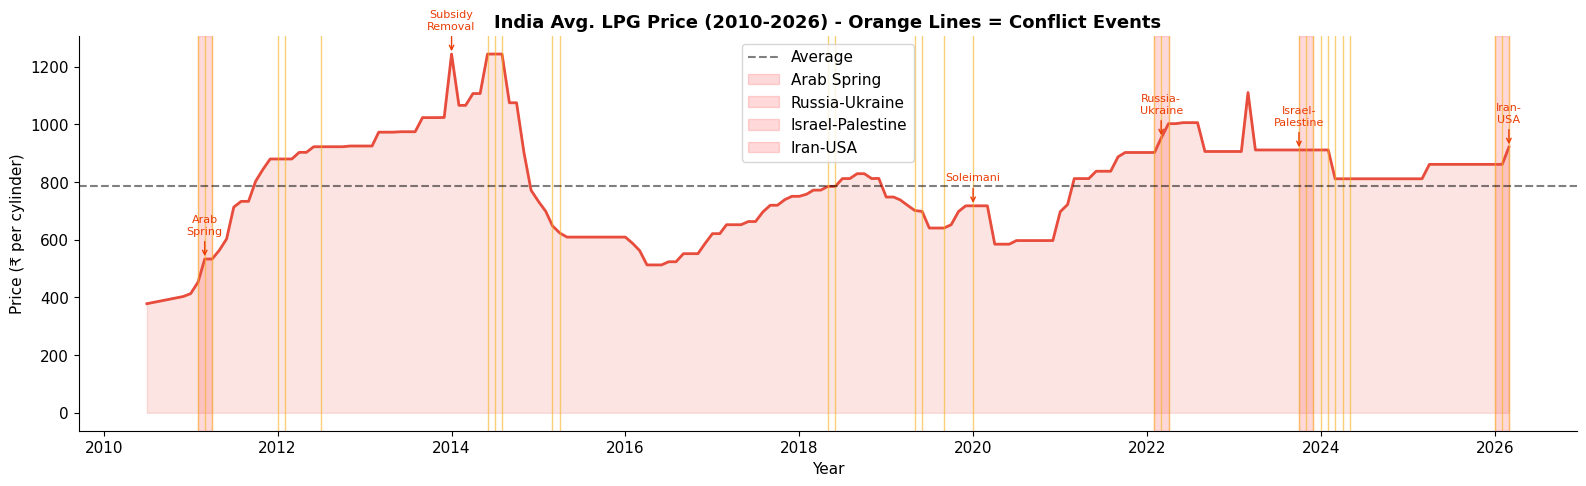

Saved : EDA_01_LPG_trend.png


In [7]:

#^ LPG price trend (with conflict mapping)

conflict_months = df[df['conflict_event'] == 1]['date']
fig, ax = plt.subplots(figsize = (16, 5))

ax.plot(df['date'], df['LPG_price'], color='#e74c3c', linewidth=2)
ax.fill_between(df['date'], df['LPG_price'], alpha=0.15, color='#e74c3c')

# todo mark conflict months
for d in conflict_months:
    ax.axvline(x=d, color="#f7b21c", alpha=0.6, linewidth=1)

ax.axhline(y=df['LPG_price'].mean(), color="#000000", alpha=0.5, linestyle='--', label='Average')

#? key events
key_events = {
    '2011-03-01': 'Arab\nSpring',
    '2014-01-01': 'Subsidy\nRemoval',
    '2020-01-01': 'Soleimani',
    '2022-03-01': 'Russia-\nUkraine',
    '2023-10-01': 'Israel-\nPalestine',
    '2026-03-01': 'Iran-\nUSA'
}

#^ mark key events on graph
for date_str, label in key_events.items():
    try:
        d = pd.to_datetime(date_str)
        y = df[df['date'] == d]['LPG_price'].values

        #~ check if that date exist
        if len(y) > 0:
            ax.annotate(label, xy= (d, y[0]), xytext=(0, 18),
                    textcoords= 'offset points', ha= 'center',
                    fontsize= 8, color= '#E93E05',
                    arrowprops= dict(arrowstyle= '->', color= '#E93E05', lw=1))
    except: pass 

#! shade conflict periods
conflict_periods = [
    ('2011-02-01', '2011-04-01', 'Arab Spring'),
    ('2022-02-01', '2022-04-01', 'Russia-Ukraine'),
    ('2023-10-01', '2023-12-01', 'Israel-Palestine'),
    ('2026-01-01', '2026-03-01', 'Iran-USA')
]

for start, end, label in conflict_periods:
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), label= label, color= 'red', alpha=0.15)

#* set labels and titles
ax.set_title('India Avg. LPG Price (2010-2026) - Orange Lines = Conflict Events')
ax.set_xlabel('Year')
ax.set_ylabel('Price (₹ per cylinder)')
ax.legend()
plt.tight_layout()

plt.savefig('C:/Users/anasq/OneDrive/Desktop/PetroAnalyst/Exploratory_Data_Analysis/EDA_Visualizations/EDA_01_LPG_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved : EDA_01_LPG_trend.png')

# Crude Oil Trend With Conflict Mapping

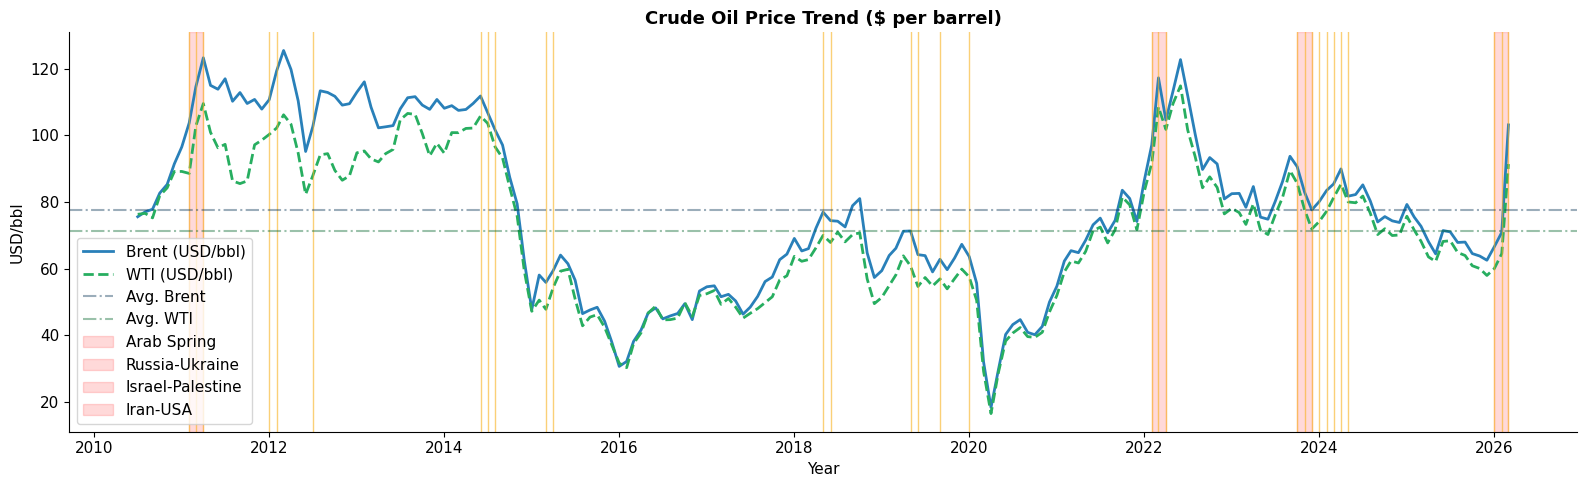

Saved : EDA_02_Crude_oil_trend.png


In [15]:

#* Brent and WTI crude oil trend
fig, ax = plt.subplots(figsize=(16,5))  

ax.plot(df['date'], df['brent_price'], color='#2980b9', linewidth=2, label='Brent (USD/bbl)')
ax.plot(df['date'], df['wti_price'], color='#27ae60', linewidth=2, label='WTI (USD/bbl)', linestyle='--')

for d in conflict_months:
    ax.axvline(x=d, color='#f7b21c', alpha=0.6, linewidth=1)

ax.axhline(df['brent_price'].mean(), color="#053454", label='Avg. Brent', alpha=0.4, linestyle='-.')
ax.axhline(df['wti_price'].mean(), color="#04642c", label= 'Avg. WTI', alpha=0.4, linestyle='-.')

#! shade conflict periods
for start, end, label in conflict_periods:
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), color='red', alpha=0.15, label=label)

ax.set_title('Crude Oil Price Trend ($ per barrel)')
ax.set_xlabel('Year')
ax.set_ylabel('USD/bbl')

plt.legend(loc='best')
plt.tight_layout()
plt.savefig('C:/Users/anasq/OneDrive/Desktop/PetroAnalyst/Exploratory_Data_Analysis/EDA_Visualizations/EDA_02_Crude_oil_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved : EDA_02_Crude_oil_trend.png')

# Geopolitical Risk Index Trend

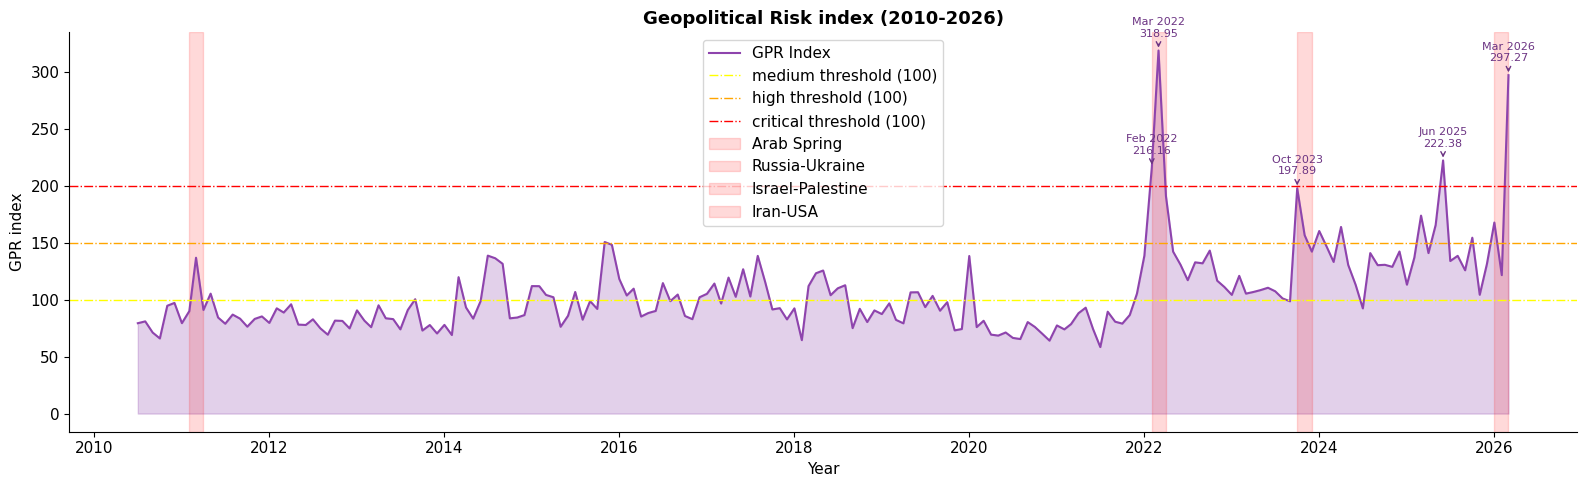

Saved : EDA_03_GPR_Trend


In [42]:

fig, ax = plt.subplots(figsize=(16,5))
ax.plot(df['date'], df['GPR_index'], color='#8e44ad', linewidth=1.5, label='GPR Index')
ax.fill_between(df['date'], df['GPR_index'], color='#8e44ad', alpha=0.25)

ax.axhline(y=100, color='yellow', label='medium threshold (100)', linestyle='-.', linewidth=1)
ax.axhline(y=150, color='orange', label='high threshold (100)', linestyle='-.', linewidth=1)
ax.axhline(y=200, color='red', label='critical threshold (100)', linestyle='-.', linewidth=1)

top5 = df.nlargest(5, 'GPR_index')
for _, row in top5.iterrows():
    ax.annotate(f"{row['date'].strftime("%b %Y")}\n{row['GPR_index']:.2f}",
                xy=(row['date'], row['GPR_index']),
                textcoords='offset points', xytext=(0,10),
                ha='center', fontsize=8, color='#6c3483',
                arrowprops=dict(arrowstyle='->', color='#6c3483', lw=1))
for start, end, label in conflict_periods:
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), label=label, color='red', alpha=0.15)

ax.set_title('Geopolitical Risk index (2010-2026)')
ax.set_xlabel('Year')
ax.set_ylabel('GPR index')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig(r'C:\Users\anasq\OneDrive\Desktop\PetroAnalyst\Exploratory_Data_Analysis\EDA_Visualizations\EDA_03_GPR_Trend', dpi=150, bbox_inches='tight')
plt.show()
print("Saved : EDA_03_GPR_Trend")

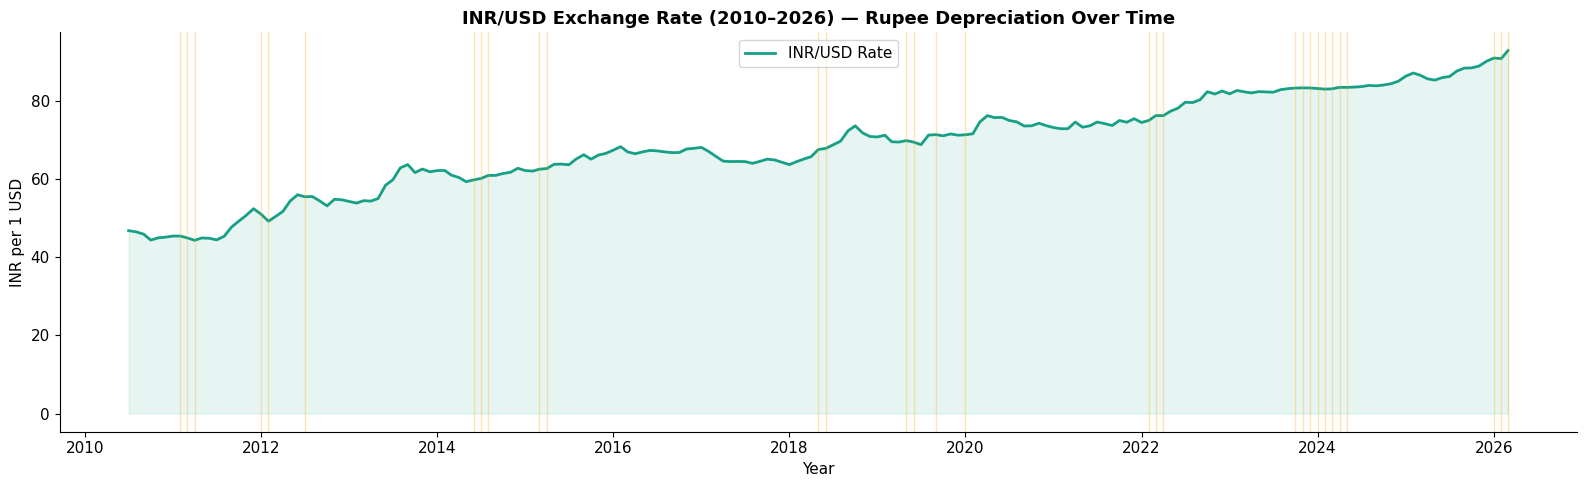

Saved: eda_04_inr_trend.png


In [8]:

#~ ─── 3d. INR/USD exchange rate trend
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df['date'], df['usd_rate'], color='#16a085', linewidth=2, label='INR/USD Rate')
ax.fill_between(df['date'], df['usd_rate'], alpha=0.1, color='#16a085')

for d in conflict_months:
    ax.axvline(x=d, color='orange', alpha=0.3, linewidth=1)

ax.set_title('INR/USD Exchange Rate (2010–2026) — Rupee Depreciation Over Time')
ax.set_ylabel('INR per 1 USD')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.savefig('eda_04_inr_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_04_inr_trend.png')

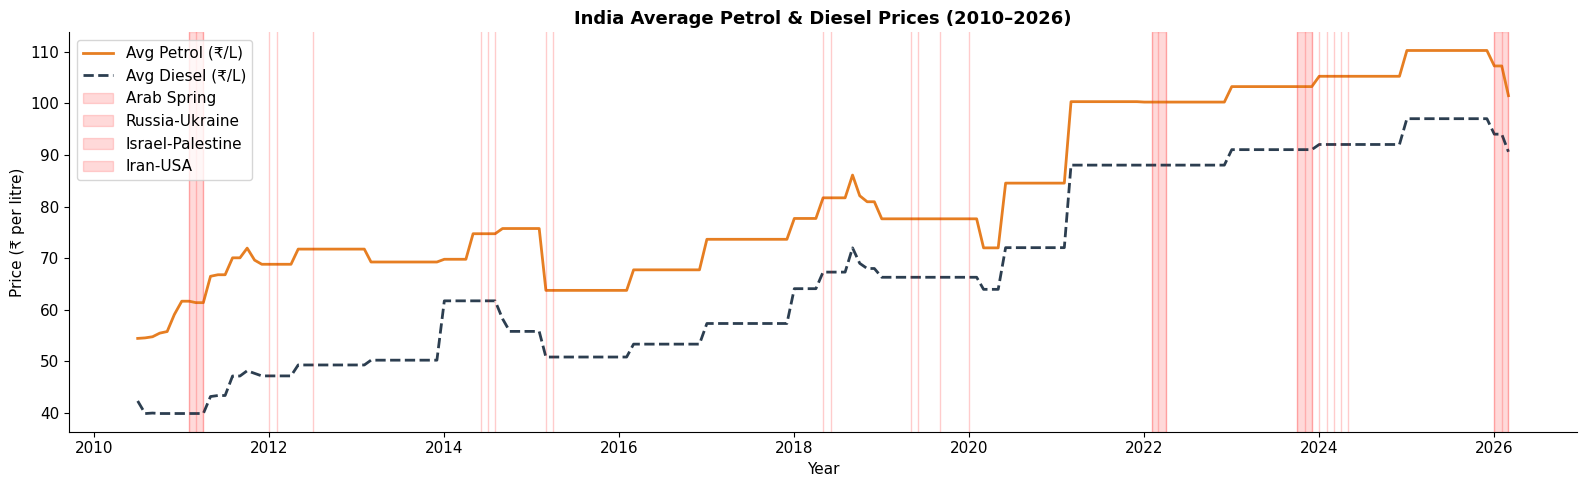

Saved: eda_05_fuel_trend.png


In [9]:

#* ─── 3e. Petrol & Diesel Trend
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df['date'], df['avg_petrol'], color='#e67e22', linewidth=2, label='Avg Petrol (₹/L)')
ax.plot(df['date'], df['avg_diesel'], color='#2c3e50', linewidth=2, label='Avg Diesel (₹/L)', linestyle='--')

for d in conflict_months:
    ax.axvline(x=d, color='red', alpha=0.2, linewidth=1)

#! Shade conflict periods
conflict_periods = [
    ('2011-02-01', '2011-04-01', 'Arab Spring'),
    ('2022-02-01', '2022-04-01', 'Russia-Ukraine'),
    ('2023-10-01', '2023-12-01', 'Israel-Palestine'),
    ('2026-01-01', '2026-03-01', 'Iran-USA'),
]
for start, end, label in conflict_periods:
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.15, color='red', label=label)

ax.set_title('India Average Petrol & Diesel Prices (2010–2026)')
ax.set_ylabel('Price (₹ per litre)')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.savefig('eda_05_fuel_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_05_fuel_trend.png')

# 4. Conflict impact analysis

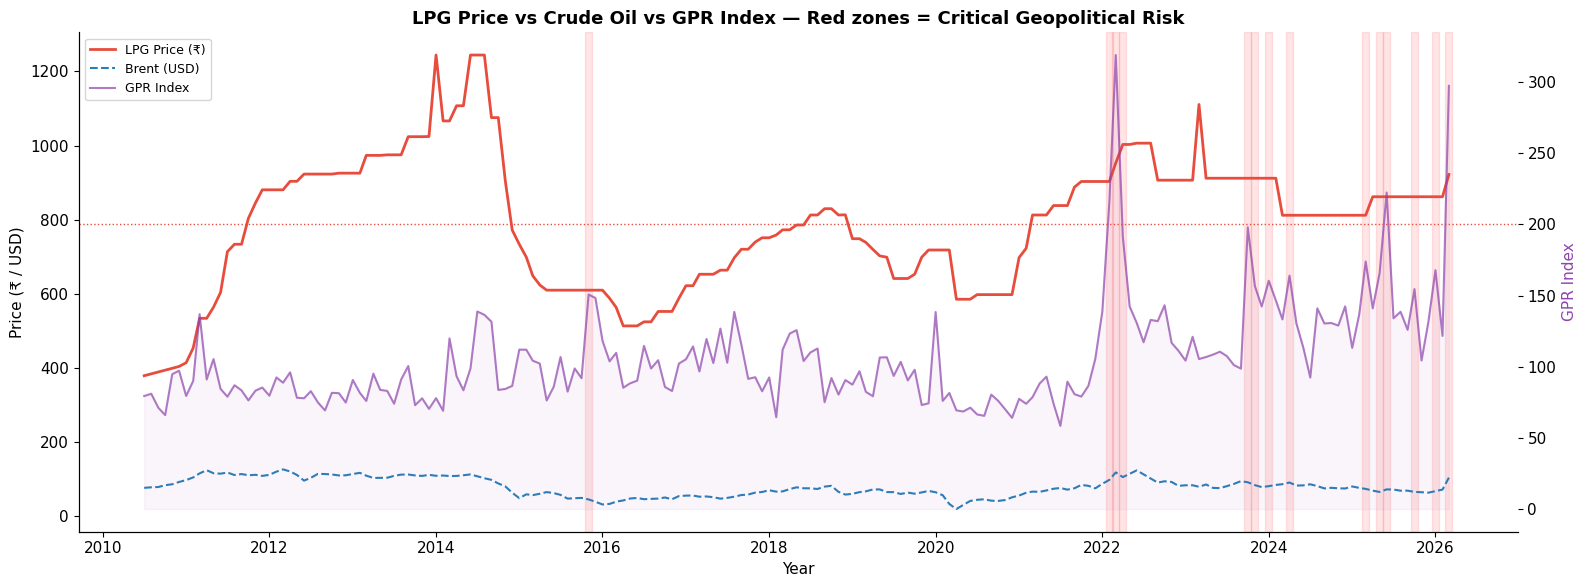

Saved: eda_06_combined_signals.png


In [10]:

#^ ─── 4a. All 4 SIGNALS On One Chart
fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

# Left axis — prices
ax1.plot(df['date'], df['avg_lpg_price'],     color='#e74c3c', linewidth=2,   label='LPG Price (₹)')
ax1.plot(df['date'], df['brent_price'], color='#2980b9', linewidth=1.5, label='Brent (USD)', linestyle='--')

# Right axis — GPR
ax2.plot(df['date'], df['GPR'], color='#8e44ad', linewidth=1.5, label='GPR Index', alpha=0.7)
ax2.fill_between(df['date'], df['GPR'], alpha=0.05, color='#8e44ad')
ax2.axhline(y=200, color='#e74c3c', linestyle=':', linewidth=1)

# Shade critical conflict periods
critical = df[df['risk_level'] >= 2]
for _, row in critical.iterrows():
    ax1.axvspan(row['date'] - pd.Timedelta(days=15),
                row['date'] + pd.Timedelta(days=15),
                alpha=0.1, color='red')

ax1.set_ylabel('Price (₹ / USD)', color='black')
ax2.set_ylabel('GPR Index', color='#8e44ad')
ax1.set_xlabel('Year')
ax1.set_title('LPG Price vs Crude Oil vs GPR Index — Red zones = Critical Geopolitical Risk')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('eda_06_combined_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_06_combined_signals.png')

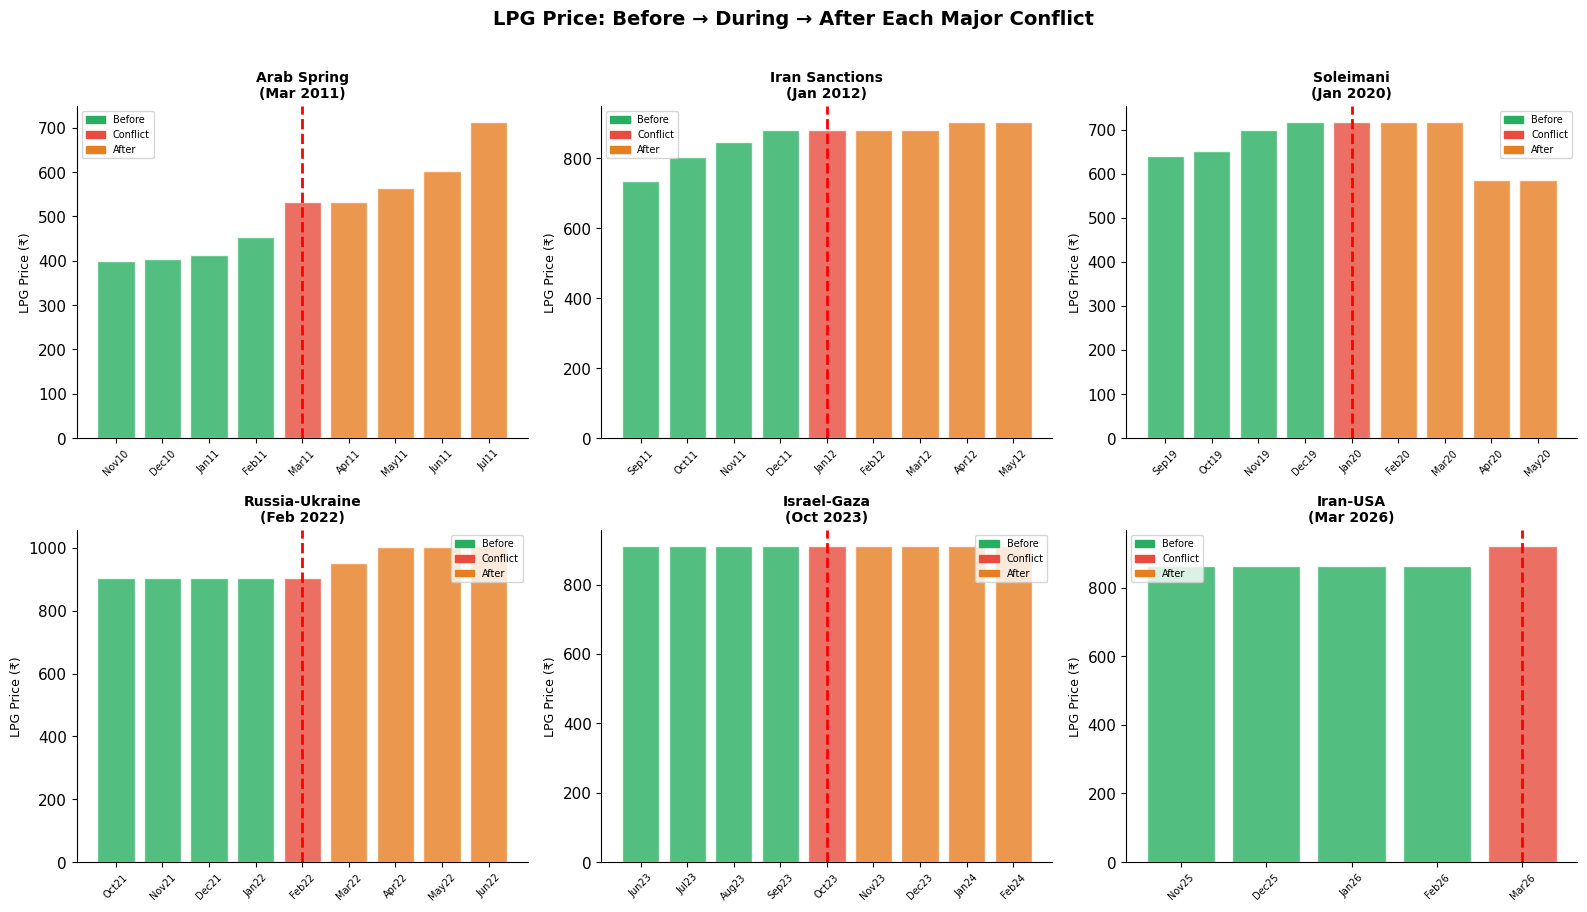

Saved: eda_07_conflict_impact.png


In [11]:

#? ─── 4b. Before vs During vs After
# For each conflict event, compare LPG price 3 months before, during, 3 months after

key_conflicts = {
    'Arab Spring\n(Mar 2011)':      '2011-03-01',
    'Iran Sanctions\n(Jan 2012)':   '2012-01-01',
    'Soleimani\n(Jan 2020)':        '2020-01-01',
    'Russia-Ukraine\n(Feb 2022)':   '2022-02-01',
    'Israel-Gaza\n(Oct 2023)':      '2023-10-01',
    'Iran-USA\n(Mar 2026)':         '2026-03-01',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, (event_name, date_str) in enumerate(key_conflicts.items()):
    event_date = pd.to_datetime(date_str)
    window = df[(df['date'] >= event_date - pd.DateOffset(months=4)) &
                (df['date'] <= event_date + pd.DateOffset(months=4))].copy()

    if len(window) == 0:
        continue

    ax = axes[idx]
    colors = ['#27ae60' if d < event_date else ('#e74c3c' if d == event_date else '#e67e22')
              for d in window['date']]

    ax.bar(range(len(window)), window['avg_lpg_price'], color=colors, alpha=0.8, edgecolor='white')
    ax.axvline(x=window['date'].tolist().index(event_date) if event_date in window['date'].tolist()
               else len(window)//2,
               color='red', linestyle='--', linewidth=2, label='Conflict')

    ax.set_title(event_name, fontsize=10)
    ax.set_ylabel('LPG Price (₹)', fontsize=9)
    ax.set_xticks(range(len(window)))
    ax.set_xticklabels([d.strftime('%b%y') for d in window['date']], rotation=45, fontsize=7)

    green_patch  = mpatches.Patch(color='#27ae60', label='Before')
    red_patch    = mpatches.Patch(color='#e74c3c', label='Conflict')
    orange_patch = mpatches.Patch(color='#e67e22', label='After')
    ax.legend(handles=[green_patch, red_patch, orange_patch], fontsize=7)

plt.suptitle('LPG Price: Before → During → After Each Major Conflict', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_07_conflict_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_07_conflict_impact.png')

=== CONFLICT vs NON-CONFLICT COMPARISON ===
Metric                     Normal     Conflict   Difference
----------------------------------------------------------
Avg LPG Price (₹)           778.2        839.9        +61.7
Avg Petrol (₹)               81.5         86.2         +4.7
Avg Diesel (₹)               66.7         71.8         +5.1
Avg Brent (USD)              75.4         88.9        +13.5


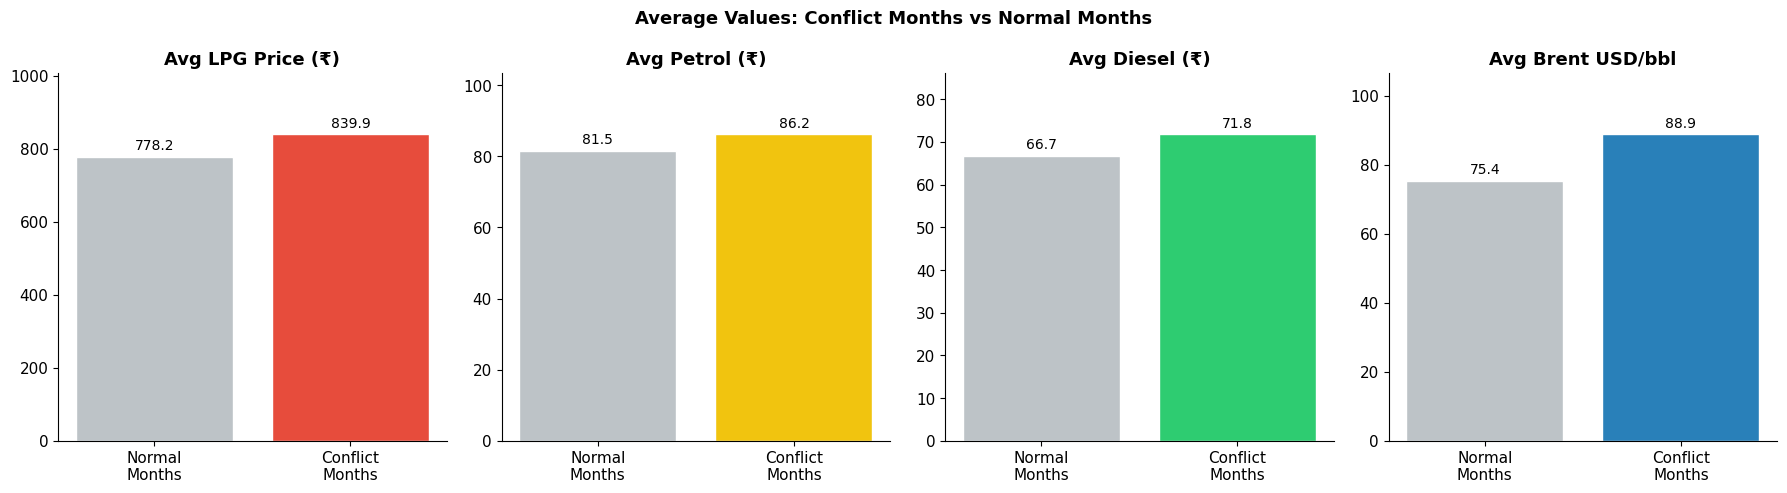

Saved: eda_08_conflict_vs_normal.png


In [12]:
#* 4c. Avg LPG Price — conflict vs non-conflict months

conflict_lpg     = df[df['conflict_event'] == 1]['avg_lpg_price'].mean()
non_conflict_lpg = df[df['conflict_event'] == 0]['avg_lpg_price'].mean()
conflict_petrol  = df[df['conflict_event'] == 1]['avg_petrol'].mean()
non_conflict_petrol = df[df['conflict_event'] == 0]['avg_petrol'].mean()
conflict_diesel  = df[df['conflict_event'] == 1]['avg_diesel'].mean()
non_conflict_diesel = df[df['conflict_event'] == 0]['avg_diesel'].mean()
conflict_brent   = df[df['conflict_event'] == 1]['brent_price'].mean()
non_conflict_brent = df[df['conflict_event'] == 0]['brent_price'].mean()

print('=== CONFLICT vs NON-CONFLICT COMPARISON ===')
print(f"{'Metric':<20} {'Normal':>12} {'Conflict':>12} {'Difference':>12}")
print('-'*58)
print(f"{'Avg LPG Price (₹)':<20} {non_conflict_lpg:>12.1f} {conflict_lpg:>12.1f} {conflict_lpg-non_conflict_lpg:>+12.1f}")
print(f"{'Avg Petrol (₹)':<20} {non_conflict_petrol:>12.1f} {conflict_petrol:>12.1f} {conflict_petrol-non_conflict_petrol:>+12.1f}")
print(f"{'Avg Diesel (₹)':<20} {non_conflict_diesel:>12.1f} {conflict_diesel:>12.1f} {conflict_diesel-non_conflict_diesel:>+12.1f}")
print(f"{'Avg Brent (USD)':<20} {non_conflict_brent:>12.1f} {conflict_brent:>12.1f} {conflict_brent-non_conflict_brent:>+12.1f}")

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = [
    ('Avg LPG Price (₹)', conflict_lpg, non_conflict_lpg, '#e74c3c'),
    ('Avg Petrol (₹)',    conflict_petrol, non_conflict_petrol, '#f1c40f'),
    ('Avg Diesel (₹)',    conflict_diesel, non_conflict_diesel, '#2ecc71'),
    ('Avg Brent USD/bbl', conflict_brent, non_conflict_brent, '#2980b9'),
]
for ax, (title, c_val, n_val, color) in zip(axes, metrics):
    # Width increased to 0.8 to reduce the gap
    bars = ax.bar(['Normal\nMonths', 'Conflict\nMonths'], [n_val, c_val],
                  color=['#bdc3c7', color], edgecolor='white', width=0.8)
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=10)
    ax.set_title(title)
    ax.set_ylim(0, max(c_val, n_val) * 1.2)

plt.suptitle('Average Values: Conflict Months vs Normal Months', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_08_conflict_vs_normal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_08_conflict_vs_normal.png')


# 5. Correlation Analysis

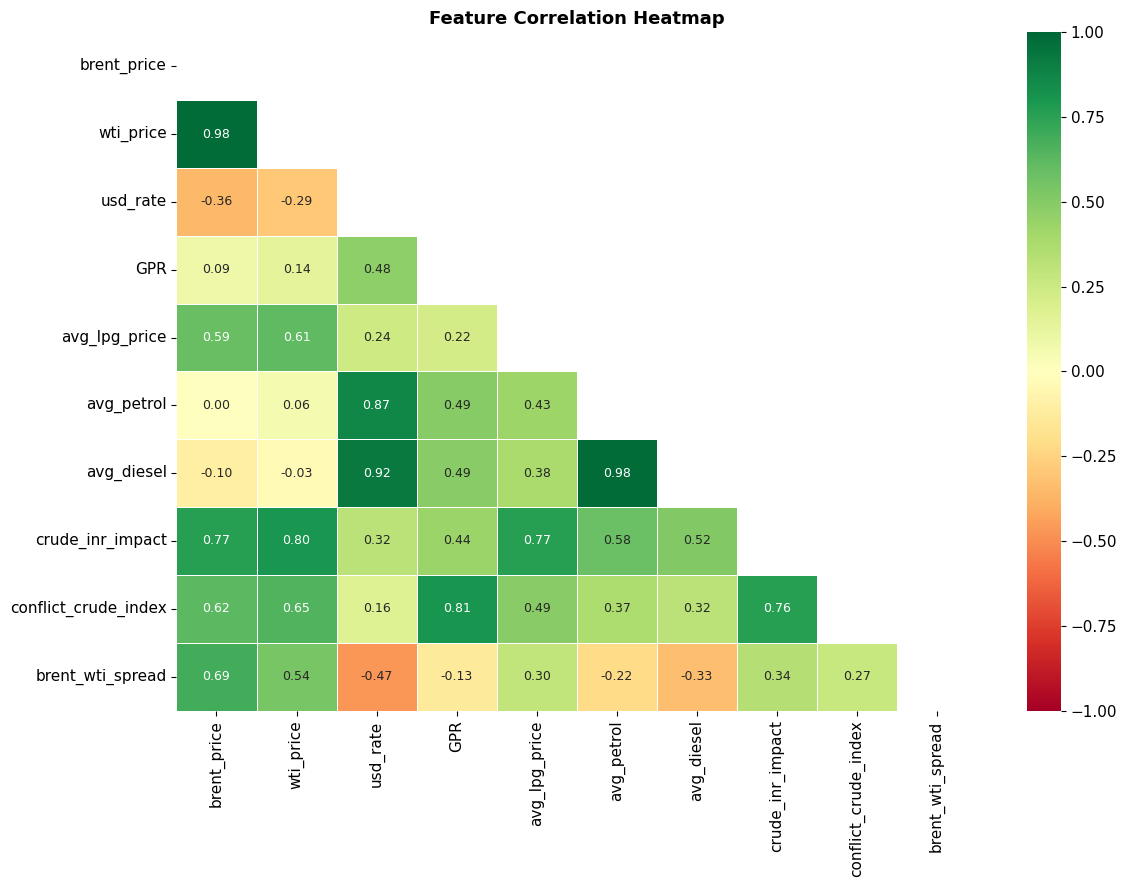

Saved: eda_09_correlation_heatmap.png


In [13]:

#todo 5a. Correlation Analysis Heatmap
corr_cols = ['brent_price','wti_price','usd_rate','GPR',
             'avg_lpg_price','avg_petrol','avg_diesel',
             'crude_inr_impact','conflict_crude_index','brent_wti_spread']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('eda_09_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_09_correlation_heatmap.png')

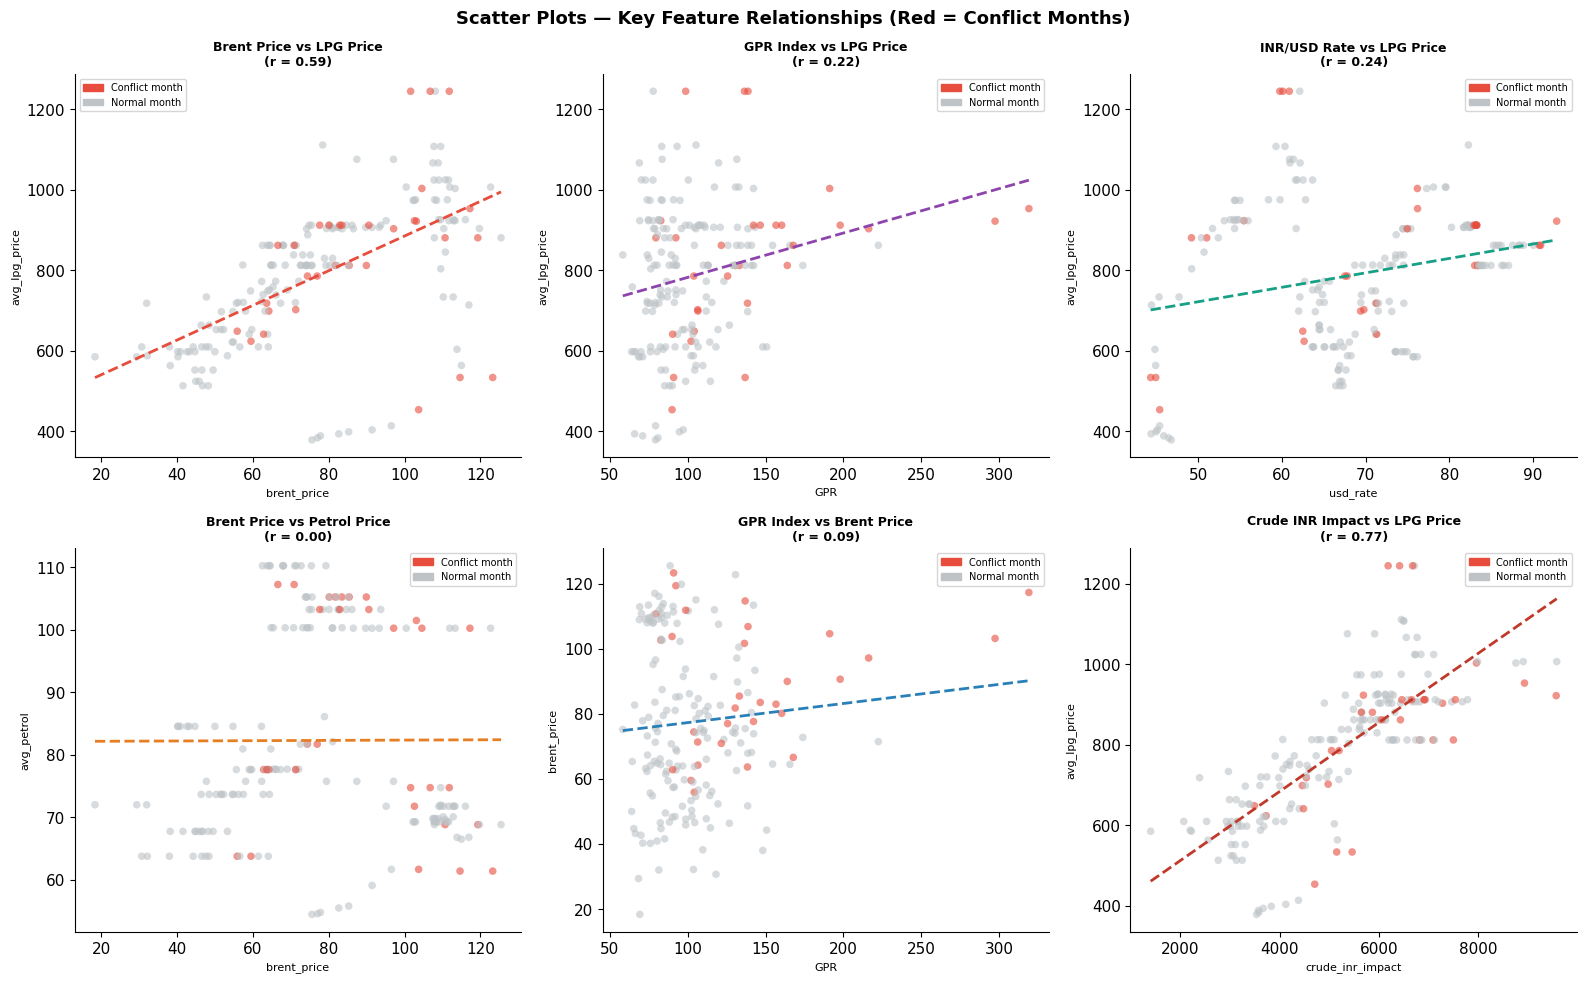

Saved: eda_10_scatter_plots.png


In [14]:

#? 5b. SCATTER PLOTS — Key realtionships
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

scatter_pairs = [
    ('brent_price', 'avg_lpg_price',    'Brent Price vs LPG Price',        '#e74c3c'),
    ('GPR',         'avg_lpg_price',    'GPR Index vs LPG Price',           '#8e44ad'),
    ('usd_rate',        'avg_lpg_price',    'INR/USD Rate vs LPG Price',        '#16a085'),
    ('brent_price', 'avg_petrol', 'Brent Price vs Petrol Price',      '#e67e22'),
    ('GPR',         'brent_price','GPR Index vs Brent Price',         '#2980b9'),
    ('crude_inr_impact','avg_lpg_price','Crude INR Impact vs LPG Price',    '#c0392b'),
]

for ax, (x, y, title, color) in zip(axes.flatten(), scatter_pairs):
    #^ Color by conflict event
    colors = df['conflict_event'].map({0: '#bdc3c7', 1: '#e74c3c'})
    ax.scatter(df[x], df[y], c=colors, alpha=0.6, s=30, edgecolors='none')

    #& Trend line
    z = np.polyfit(df[x].dropna(), df[y].dropna(), 1)
    p = np.poly1d(z)
    xline = np.linspace(df[x].min(), df[x].max(), 100)
    ax.plot(xline, p(xline), color=color, linewidth=2, linestyle='--')

    corr = df[[x, y]].corr().iloc[0, 1]
    ax.set_title(f'{title}\n(r = {corr:.2f})', fontsize=9)
    ax.set_xlabel(x, fontsize=8)
    ax.set_ylabel(y, fontsize=8)

    red_dot   = mpatches.Patch(color='#e74c3c', label='Conflict month')
    grey_dot  = mpatches.Patch(color='#bdc3c7', label='Normal month')
    ax.legend(handles=[red_dot, grey_dot], fontsize=7)

plt.suptitle('Scatter Plots — Key Feature Relationships (Red = Conflict Months)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_10_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_10_scatter_plots.png')

# 6. Lag & Dealy pattern analysis

Best lag for GPR --> LPG:   0 months (corr=0.223)
Best lag for Brent --> LPG: 4 months (corr=0.671)


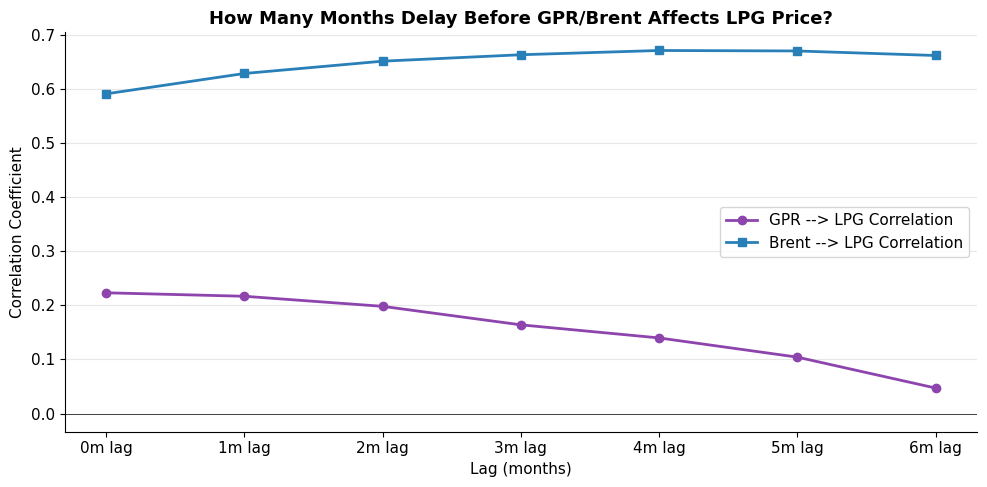

Saved: eda_11_lag_correlation.png


In [15]:

#* 6a. Lag correlation — GPR → LPG delay

lags = range(0, 7)
lag_corr_gpr_lpg   = [df['GPR'].shift(lag).corr(df['avg_lpg_price']) for lag in lags]
lag_corr_brent_lpg = [df['brent_price'].shift(lag).corr(df['avg_lpg_price']) for lag in lags]

fig, ax = plt.subplots(figsize=(10, 5))
x = list(lags)
ax.plot(x, lag_corr_gpr_lpg,   marker='o', color='#8e44ad', linewidth=2, label='GPR --> LPG Correlation')
ax.plot(x, lag_corr_brent_lpg, marker='s', color='#2980b9', linewidth=2, label='Brent --> LPG Correlation')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Correlation Coefficient')
ax.set_title('How Many Months Delay Before GPR/Brent Affects LPG Price?')
ax.set_xticks(x)
ax.set_xticklabels([f'{l}m lag' for l in x])
ax.legend()
ax.grid(axis='y', alpha=0.3)

best_gpr_lag   = lag_corr_gpr_lpg.index(max(lag_corr_gpr_lpg))
best_brent_lag = lag_corr_brent_lpg.index(max(lag_corr_brent_lpg))
print(f'Best lag for GPR --> LPG:   {best_gpr_lag} months (corr={max(lag_corr_gpr_lpg):.3f})')
print(f'Best lag for Brent --> LPG: {best_brent_lag} months (corr={max(lag_corr_brent_lpg):.3f})')

plt.tight_layout()
plt.savefig('eda_11_lag_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_11_lag_correlation.png')

# 7. Risk level distribution

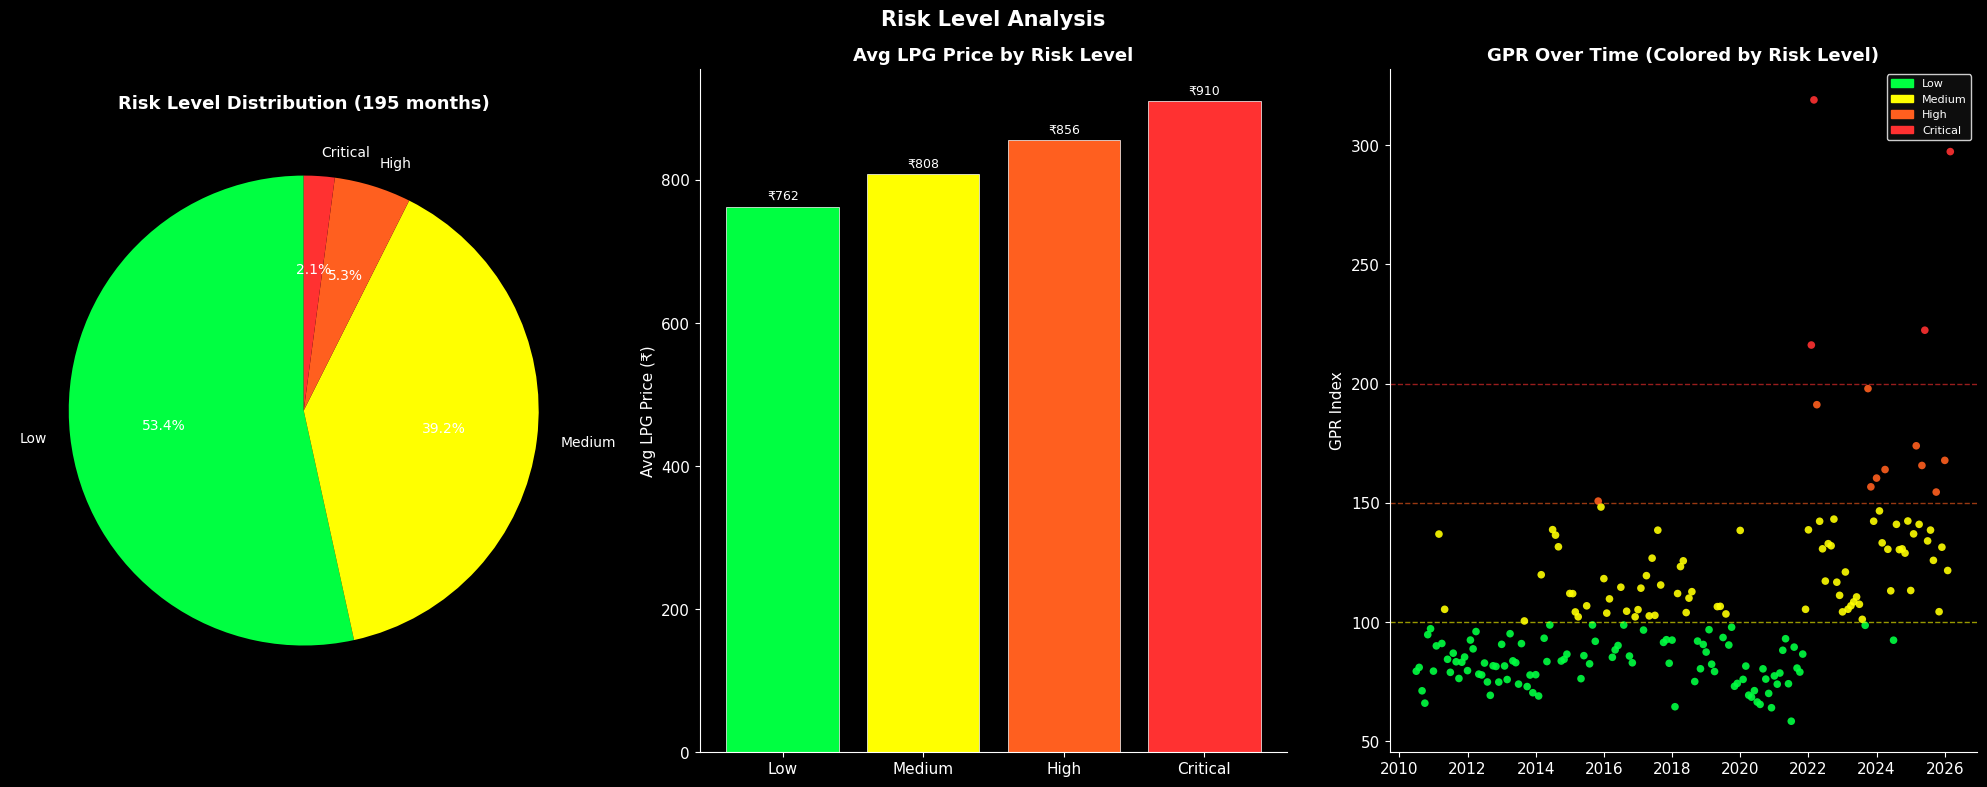

Saved: eda_12_risk_distribution_neon.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Updated risk_colors for a neon aesthetic
risk_map    = {0:'Low', 1:'Medium', 2:'High', 3:'Critical'}
risk_colors = {
    0: "#00FF41",  # Neon Green
    1: "#FFFF00",  # Neon Yellow
    2: "#FF5F1F",  # Neon Orange
    3: "#FF3131"   # Neon Red
}
df['risk_label'] = df['risk_level'].map(risk_map)

# Set the global dark theme
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 3, figsize=(20, 8), facecolor='black')

# Pie chart
counts = df['risk_label'].value_counts()
pie_colors = [risk_colors[k] for k in [0,1,2,3] if risk_map[k] in counts.index]
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=pie_colors, startangle=90, 
            textprops={'fontsize': 10, 'color': 'white'})
axes[0].set_title('Risk Level Distribution (195 months)', color='white')
axes[0].set_facecolor('black')

# Bar chart with avg LPG per risk level
risk_lpg = df.groupby('risk_label')['avg_lpg_price'].mean().reindex(['Low','Medium','High','Critical'])
bars = axes[1].bar(risk_lpg.index, risk_lpg.values,
                   color=[risk_colors[0], risk_colors[1], risk_colors[2], risk_colors[3]],
                   edgecolor='white', linewidth=0.5)
axes[1].bar_label(bars, fmt='₹%.0f', padding=3, fontsize=9, color='white')
axes[1].set_title('Avg LPG Price by Risk Level', color='white')
axes[1].set_ylabel('Avg LPG Price (₹)', color='white')
axes[1].set_facecolor('black')

# Risk level over time
risk_colors_list = df['risk_level'].map(risk_colors)
axes[2].scatter(df['date'], df['GPR'], c=risk_colors_list, s=30, alpha=0.9, edgecolors='none')
# Neon threshold lines
axes[2].axhline(y=100, color=risk_colors[1], linestyle='--', linewidth=1, alpha=0.6)
axes[2].axhline(y=150, color=risk_colors[2], linestyle='--', linewidth=1, alpha=0.6)
axes[2].axhline(y=200, color=risk_colors[3], linestyle='--', linewidth=1, alpha=0.6)
axes[2].set_title('GPR Over Time (Colored by Risk Level)', color='white')
axes[2].set_ylabel('GPR Index', color='white')
axes[2].set_facecolor('black')

# Legend and Layout styling
patches = [mpatches.Patch(color=risk_colors[k], label=risk_map[k]) for k in range(4)]
axes[2].legend(handles=patches, fontsize=8, facecolor='#111111', edgecolor='white')

plt.suptitle('Risk Level Analysis', fontsize=15, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig('eda_12_risk_distribution_neon.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print('Saved: eda_12_risk_distribution_neon.png')


# 8. India Import Dependency (Middle East)

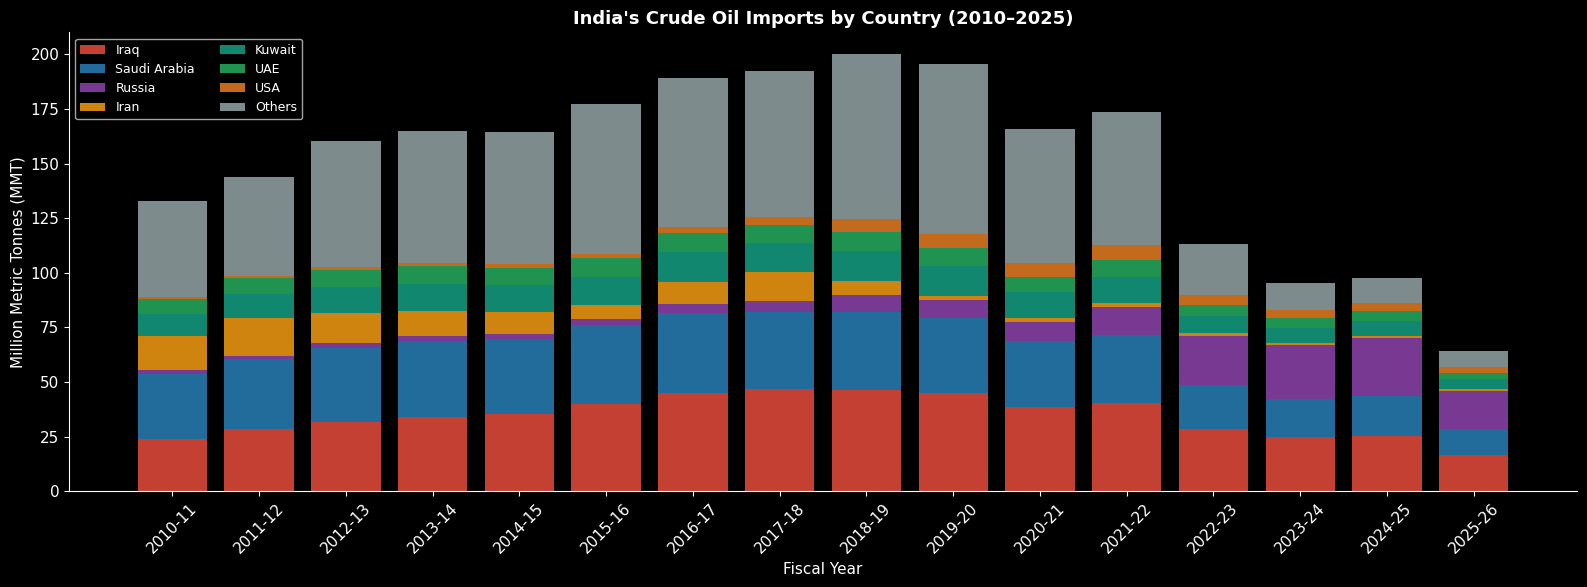

Saved: eda_13_import_dependency.png


In [17]:

#& 8a. STACKED BAR — COUNTRY-WISE IMPORTS
country_cols = ['iraq_mmt','saudi_arabia_mmt','russia_mmt',
                'iran_mmt','kuwait_mmt','uae_mmt','usa_mmt','others_mmt']
country_labels = ['Iraq','Saudi Arabia','Russia','Iran','Kuwait','UAE','USA','Others']
country_colors = ['#e74c3c','#2980b9','#8e44ad','#f39c12','#16a085','#27ae60','#e67e22','#95a5a6']

fig, ax = plt.subplots(figsize=(16, 6))
bottom = np.zeros(len(imports))
for col, label, color in zip(country_cols, country_labels, country_colors):
    if col in imports.columns:
        vals = imports[col].values
        ax.bar(imports['year'], vals, bottom=bottom, label=label, color=color, alpha=0.85)
        bottom += vals

ax.set_title("India's Crude Oil Imports by Country (2010–2025)", fontsize=13, fontweight='bold')
ax.set_ylabel('Million Metric Tonnes (MMT)')
ax.set_xlabel('Fiscal Year')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig('eda_13_import_dependency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_13_import_dependency.png')

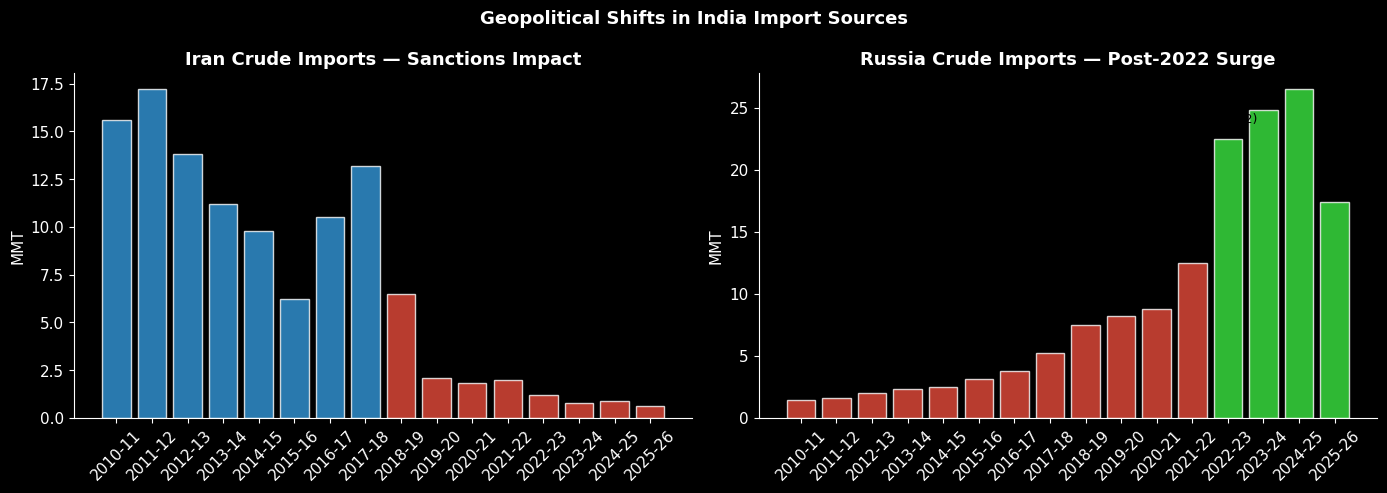

Saved: eda_14_iran_russia_imports.png


In [18]:

#* 8b. IRAN IMPORTS — BEFORE vs AFTER SANCTIONS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Iran imports over years
if 'iran_mmt' in imports.columns:
    axes[0].bar(imports['year'], imports['iran_mmt'],
                color=['#e74c3c' if y >= '2018-19' else '#3498db' for y in imports['year']],
                alpha=0.8, edgecolor='white')
    axes[0].axvline(x=7.5, color='black', linestyle='--', linewidth=2)
    axes[0].text(7.7, imports['iran_mmt'].max() * 0.9, 'US exits\nJCPOA\n(2018)',
                 fontsize=9, color='black')
    axes[0].set_title('Iran Crude Imports — Sanctions Impact')
    axes[0].set_ylabel('MMT')
    axes[0].tick_params(axis='x', rotation=45)

# Russia imports — rise after 2022
if 'russia_mmt' in imports.columns:
    axes[1].bar(imports['year'], imports['russia_mmt'],
                color=["#3ce742" if y >= '2022-23' else '#e74c3c' for y in imports['year']],
                alpha=0.8, edgecolor='white')
    axes[1].axvline(x=11.5, color='black', linestyle='--', linewidth=2)
    axes[1].text(11.7, imports['russia_mmt'].max() * 0.9, 'Russia-\nUkraine\n(2022)',
                 fontsize=9, color='black')
    axes[1].set_title('Russia Crude Imports — Post-2022 Surge')
    axes[1].set_ylabel('MMT')
    axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Geopolitical Shifts in India Import Sources', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_14_iran_russia_imports.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_14_iran_russia_imports.png')

# 9. Key fndings & summary

In [19]:

#todo 9. PRINT ALL KEY FINDINGS
print('='*60)
print('         EDA KEY FINDINGS SUMMARY')
print('='*60)

print('\n PRICE GROWTH (2010 → 2026):')
print(f"  LPG:    ₹{df['avg_lpg_price'].iloc[0]:.0f} → ₹{df['avg_lpg_price'].iloc[-1]:.0f}  (+{((df['avg_lpg_price'].iloc[-1]/df['avg_lpg_price'].iloc[0])-1)*100:.0f}%)")
print(f"  Petrol: ₹{df['avg_petrol'].iloc[0]:.0f} → ₹{df['avg_petrol'].iloc[-1]:.0f}  (+{((df['avg_petrol'].iloc[-1]/df['avg_petrol'].iloc[0])-1)*100:.0f}%)")
print(f"  INR:    {df['usd_rate'].iloc[0]:.1f} → {df['usd_rate'].iloc[-1]:.1f}  (Rupee depreciated {((df['usd_rate'].iloc[-1]/df['usd_rate'].iloc[0])-1)*100:.0f}%)")

print('\n CONFLICT IMPACT:')
print(f"  Avg LPG during conflict: ₹{df[df['conflict_event']==1]['avg_lpg_price'].mean():.0f}")
print(f"  Avg LPG during normal:   ₹{df[df['conflict_event']==0]['avg_lpg_price'].mean():.0f}")
diff = df[df['conflict_event']==1]['avg_lpg_price'].mean() - df[df['conflict_event']==0]['avg_lpg_price'].mean()
print(f"  Difference: ₹{diff:.0f} higher during conflicts")

print('\n CORRELATIONS WITH LPG PRICE:')
for col in ['brent_price','wti_price','usd_rate','GPR','crude_inr_impact']:
    corr = df[col].corr(df['avg_lpg_price'])
    print(f"  {col:<25}: {corr:+.3f}")

print('\n  TOP 5 HIGHEST RISK MONTHS:')
top5 = df.nlargest(5, 'GPR')[['date','GPR','brent_price','avg_lpg_price','risk_label']]
print(top5.to_string(index=False))

print('\n EDA COMPLETE — 14 charts saved.')
print('   Next step: ML Algorithms')

         EDA KEY FINDINGS SUMMARY

 PRICE GROWTH (2010 → 2026):
  LPG:    ₹378 → ₹922  (+144%)
  Petrol: ₹54 → ₹102  (+86%)
  INR:    46.8 → 92.8  (Rupee depreciated 99%)

 CONFLICT IMPACT:
  Avg LPG during conflict: ₹840
  Avg LPG during normal:   ₹778
  Difference: ₹62 higher during conflicts

 CORRELATIONS WITH LPG PRICE:
  brent_price              : +0.591
  wti_price                : +0.610
  usd_rate                 : +0.244
  GPR                      : +0.223
  crude_inr_impact         : +0.766

  TOP 5 HIGHEST RISK MONTHS:
      date    GPR  brent_price  avg_lpg_price risk_label
2022-03-01 318.95       117.25          952.9   Critical
2026-03-01 297.27       103.13          921.7   Critical
2025-06-01 222.38        71.44          861.7   Critical
2022-02-01 216.16        97.13          902.9   Critical
2023-10-01 197.89        90.60          911.7       High

 EDA COMPLETE — 14 charts saved.
   Next step: ML Algorithms
